# AR segmentation: dataset and dataloader

This notebook mirrors `template/0_dataset_dataloader_template.ipynb` for the active-region (AR)
segmentation task. It builds a dataset that pairs a 13-channel SDO image stack with a binary
4096x4096 mask of active regions, and wraps it in a DataLoader.

The masks come from the [surya-bench-ar-segmentation](https://huggingface.co/datasets/nasa-ibm-ai4science/surya-bench-ar-segmentation)
dataset: hourly maps derived from HMI line-of-sight magnetograms (thresholded at +/-50 G,
small regions removed, 10 px dilation) keeping only regions that contain a polarity inversion
line (PIL). Each `.h5` file holds two keys: `intersection` (the PILs) and `union_with_intersect`
(the AR footprints, the default target).

### The whole exercise in one picture

The goal is to teach a computer to outline **active regions** — the magnetically violent
patches that produce flares. Four notebooks split it into *get the data* (this one), *try
something deliberately dumb* (1), *try something big* (2), and *find out how much to trust the
result* (3). It is a **measurement**, not a model-building project: Notebook 1 produces a
number that Notebook 2 has to beat, and Notebook 3 says whether the difference is real.

```mermaid
flowchart LR
    A[SDO images<br/>13 channels, every 12 min] --> P[Pair by exact<br/>timestamp]
    M[HMI magnetogram] --> R[Marking rule<br/>±50 G · ≥100 px · grow 10 px · needs a PIL] --> K[Answer key<br/>hourly outlines] --> P
    P --> D[DataLoader<br/>batches of 13 × 4096 × 4096]
    D --> N1[Notebook 1<br/>14-number baseline]
    D --> N2[Notebook 2<br/>Surya + adapters]
    N1 --> N3[Notebook 3<br/>intervals · calibration · label floor]
    N2 --> N3
```

*Diagrams are Mermaid; JupyterLab 4.1+ renders them.*

### Companion documents

| document | what it is for |
|---|---|
| `NOTEBOOKS_EXPLAINED.md` | all four notebooks and the labelling rule, in plain language |
| `GROUND_TRUTH_EXPLAINED.md` | where the answer key comes from, how it is made, how faithfully it reproduces |
| `ERRORS_NOTEBOOK_EXPLAINED.md` | the error-analysis notebook, section by section |


In [7]:
# Must be set BEFORE torch is imported: cuBLAS reads this once, when it initializes, so
# setting it later has no effect. (Restart the kernel if torch was already imported.)
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import sys
import numpy as np
import matplotlib.pyplot as plt
import torch

# Gives the notebook access to workshop_infrastructure/ and downstream_apps/.
sys.path.append("../../")

from workshop_infrastructure.utils import build_scalers  # per-channel normalization stats

torch.set_float32_matmul_precision("medium")

## Load configuration

The config is the single source of truth. `load_ar_config()` parses `configs/config_script.yaml`
into a typed object, exactly as `finetune_ar_segmentation.py` does, so the same YAML behaves
identically here and in the script.

The `data:` section is parsed into `ARDataConfig` (see `configs.py`), which adds the AR-specific
keys on top of the shared `DataConfig`:

| key | meaning |
|---|---|
| `ar_mask_dir` | directory with the split CSVs and `data/YYYY/MM/*.h5` masks |
| `ar_mask_splits` | which mask CSVs to load (the Surya index decides train vs validation) |
| `ar_mask_key` | `union_with_intersect` (AR footprints) or `intersection` (the PILs) |
| `ar_pooling` | block-mean pooling of inputs and mask; 1 = native 4096x4096 |
| `ar_pos_weight` | up-weights AR pixels in the BCE loss (they are ~1.3 % of the disk) |
| `ar_threshold` | probability cut for IoU / Dice / precision / recall |

`AR_CONFIG` lets you point at a different YAML (for example one with local indices) without
editing the notebook.

Two properties of the config system matter when you edit the YAML:

| property | consequence |
|---|---|
| **Unknown keys raise** | a typo is an error naming the valid alternatives, never a silent no-op; task-specific keys need a field on `ARDataConfig` |
| **Paths are relative to the config file** | a checked-in config works from any working directory; `s3_cache_dir` is the exception — it expands `~`/`$VARS` but is never anchored to the repo |


In [8]:
from downstream_apps.ar_segmentation.configs import load_ar_config

config_path = os.environ.get("AR_CONFIG", "./configs/config_script.yaml")
cfg = load_ar_config(config_path)
print(f"Loaded config for job: {cfg.job_id}")
print(f"  train index : {cfg.data.train_data_path}")
print(f"  masks       : {cfg.data.ar_mask_dir}  (key: {cfg.data.ar_mask_key})")
print(f"  s3 cache    : {cfg.data.s3_cache_dir}")

Loaded config for job: ar_segmentation_baseline
  train index : /home/jovyan/surya_workshop/data/indices/surya_aws_s3_train.csv
  masks       : /home/jovyan/surya_workshop/downstream_apps/ar_segmentation/data/surya-bench-ar-segmentation  (key: union_with_intersect)
  s3 cache    : /home/jovyan/.cache/surya_workshop/helio_s3_cache


## Download assets

`ensure_assets()` fetches only what is missing from HuggingFace, so re-running this is free.
The AR masks are a separate dataset; fetch them once with `bash download_masks.sh` (about
1.3 GB, no login needed). The SDO inputs stream from the public `nasa-surya-bench` S3 bucket,
which needs a local cache directory: set `SURYA_WS_CACHE_DIR` or `data.s3_cache_dir`
(budget roughly 1 GB per unique timestep).

### The three "spaces" the data lives in

The pipeline is signum-log **then** z-score, so there are two different "inverse" operations:

| space | what the numbers are | how you get there |
|---|---|---|
| **normalised** | what the model sees: `sign(x)·log(1+|x|)`, then z-scored per channel | the dataset's `__getitem__` |
| **signum-log** | z-score undone, log compression kept | `scaler.inverse_transform()` — what the baseline consumes via `destandardize_channels` |
| **physical** | DN for the ultraviolet channels, **gauss** for the magnetic ones | `dataset.inverse_transform_data()` — for plotting, and for re-running the labelling rule |

Never assume one is the other; the reference block is at the top of
`workshop_infrastructure/datasets/helio.py`.

Budget for the image cache: about **590 MB per unique timestep**, downloaded once. The config
points it at scratch storage; `/home` on this machine would not hold a real run.


In [9]:
from workshop_infrastructure.assets import ensure_assets

ensure_assets(cfg, which=['scalers'])

scalers = build_scalers(info=cfg.data.scalers_path)
print(f"Loaded scalers for {len(scalers)} channels.")

Loaded scalers for 13 channels.


## Define the downstream (DS) dataset

`ARSegmentationDataset` (in `datasets/ar_dataset.py`) extends `HelioNetCDFDataset`. The base
class handles everything about the *inputs*: reading NetCDF from disk or S3, the signum-log
normalization, and frame sampling. The subclass adds only the label:

1. read the mask split CSVs (`timestamp, file_path, present`), keep `present == 1`;
2. intersect their timestamps **exactly** with the Surya index timesteps;
3. in `__getitem__`, load the `.h5` mask (stored as 0/255 uint8) and return it as a float32
   0/1 array under the key `forecast`.

Two things follow from the exact match. Masks are hourly and SDO is every 12 minutes, so only
on-the-hour SDO timesteps can pair. And because the label is a mask rather than a future SDO
frame, the subclass sets `load_forecast_frames=False`, which also removes the base class's
requirement that the *t + 60 min* frame exists.

**_Important: `max_number_of_samples` caps the dataset so exploring is fast. Keep this in mind
later if the dataset seems smaller than you expect._**

### How the outlines were made

Nobody hand-drew them. They are the **ARPIL** task of SuryaBench (Roy *et al.*, *Scientific
Data* 13, 712, 2026), computed hourly from the HMI line-of-sight magnetogram by a fixed rule.
Quotations are from the paper; the full account is in `GROUND_TRUTH_EXPLAINED.md`.

| step | the paper says | effect |
|---|---|---|
| 1 threshold | "magnetic field strength threshold of +50 and −50 Gauss" | two black-and-white maps, one per polarity |
| 2 size filter | "excludes regions smaller than 100 pixels (approximately 13.3 Mm²)" — before dilation | noise and small elements removed |
| 3 dilation | "a rectangular filter of size 10 pixels" | every patch grown 10 px with a square brush; opposite polarities within ~20 px now overlap |
| 4 intersection | "the intersection of the dilated positive and negative polarity regions" | the **PIL map** — where field toward us meets field away |
| 5 selection | "Only ARs that include PILs are reported" | strong **unipolar** patches are dropped on purpose |
| 6 output | "2D bitmaps ... 4096 × 4096" | two maps per hour |

Step 5 is why a huge, strong, single-polarity patch is *not* labelled — and why a model that
flags one later has disagreed with a definition, not necessarily misperceived the Sun.

### How images and outlines are paired

| rule | consequence |
|---|---|
| Outlines are **hourly**; images are every **12 minutes** | only on-the-hour images pair — about 1 in 5 |
| Pairing is an **exact timestamp match** | no interpolation, no nearest-neighbour |
| Only catalogue rows with `present == 1` are used | hours with no valid magnetogram are dropped |
| Both maps are loaded as `> 0` | the two keys are stored differently (0/255 and 0/1); this makes both a float 0/1 image |
| Train vs validation is decided by the **image** index | the four outline CSVs are loaded only as a lookup table; the image index's validation set is mid-to-late January each year, and the two do not overlap in time |
| No vertical flips | the base loader would flip the image but not the outline |


In [10]:
from downstream_apps.ar_segmentation.datasets.ar_dataset import ARSegmentationDataset

## Initialize without Surya stacks

`return_surya_stack=False` skips loading the SDO data so the label side can be checked quickly:
nothing is read from S3 in this cell, only the mask CSVs and the small `.h5` files.

### What is in a mask file, and in the catalogues

Each hour is one HDF5 file, `data/YYYY/MM/YYYYMMDD_HHMM.h5`, about 53 KB:

| key | holds | stored as |
|---|---|---|
| `intersection` | the PIL map | 0 / **1** |
| `union_with_intersect` | active-region footprints that contain a PIL — **the default target** | 0 / **255** |

The PIL map is always a strict subset of the footprint map. The two encodings differ, which is
why the loader binarises with `> 0`.

| catalogue | covers |
|---|---|
| `train.csv` | 15 Feb – 31 Dec, 2010–2019 |
| `validation.csv` | 15 – 31 Jan, 2010–2019 |
| `leaky_validation.csv` | 1 – 14 Jan and 1 – 14 Feb, 2010–2019 |
| `test.csv` | 2020 – 2024 |

128,352 hourly rows, **121,963 with a mask** (`present == 1`), 13 May 2010 – 31 Dec 2024.


In [12]:
train_dataset = ARSegmentationDataset(
    #### All these lines are required by the parent HelioNetCDFDataset class
    index_path=cfg.data.train_data_path,
    time_delta_input_minutes=cfg.data.time_delta_input_minutes,
    time_delta_target_minutes=cfg.data.time_delta_target_minutes,
    n_input_timestamps=cfg.model.time_embedding.time_dim,
    rollout_steps=cfg.rollout_steps,
    channels=cfg.data.channels,
    drop_hmi_probability=cfg.drop_hmi_probability,
    use_latitude_in_learned_flow=cfg.use_latitude_in_learned_flow,
    scalers=scalers,
    phase="train",
    s3_mode=cfg.data.s3_mode,
    s3_storage_options={"anon": cfg.data.s3_anon},
    s3_cache_dir=cfg.data.s3_cache_dir,
    pooling=cfg.data.ar_pooling,
    #### Downstream (DS) specific parameters
    return_surya_stack=False,
    max_number_of_samples=6,
    ds_mask_dir=cfg.data.ar_mask_dir,
    ds_mask_splits=cfg.data.ar_mask_splits,
    ds_mask_key=cfg.data.ar_mask_key,
)

# Notebooks 1 and 2 skip this block: build_helio_dataloaders() fills in everything above the
# "downstream specific" line straight from the config.
print(f"{len(train_dataset)} samples (capped at max_number_of_samples)")

6 samples (capped at max_number_of_samples)


## Test length and structure

Each item is a dictionary. Without the Surya stack it holds only the label (`forecast`) and the
timestamp (`ds_index`).

| key | type / shape | meaning |
|---|---|---|
| `forecast` | float32 `(4096, 4096)`, values {0, 1} | the outline |
| `ds_index` | ISO string | the timestamp |

With `return_surya_stack=True` (later) the sample also carries `ts` and `time_delta_input`.


In [13]:
item = train_dataset[0]
print(item.keys())
mask = item["forecast"]
print(f"timestamp: {item['ds_index']}")
print(f"mask: shape={mask.shape} dtype={mask.dtype} values={np.unique(mask)} "
      f"AR fraction={mask.mean():.4%}")

dict_keys(['forecast', 'ds_index'])
timestamp: 2010-05-13T01:00:00
mask: shape=(4096, 4096) dtype=float32 values=[0. 1.] AR fraction=0.0676%


The AR fraction is the number to remember: active regions cover on the order of **1 % of the
disk**. A model that predicts "background everywhere" is ~99 % pixel-accurate and useless, which
is why the metrics in this app are IoU and Dice, not accuracy.

### How much of the Sun is active region — it depends on the year

Measured from the released outlines:

| year | AR coverage | background : AR |
|---|---|---|
| 2010 | 0.19 % | 516 : 1 |
| 2011 | 1.00 % | 100 : 1 |
| 2013 | 1.37 % | 73 : 1 |
| **2014** | **1.80 %** | **55 : 1** |
| 2016 | 0.47 % | 215 : 1 |
| 2019 | 0.023 % | 4285 : 1 |

A 78-fold swing over the 11-year solar cycle. "About 1 % of the disk" is a solar-maximum
figure. Two things follow: the imbalance a model faces depends on *which years* it sees, and
`max_samples` takes the **earliest** timestamps — mid-January 2011, about one pixel in a
thousand. `3_errors_ar.ipynb` shows what that does to training and how to choose better.


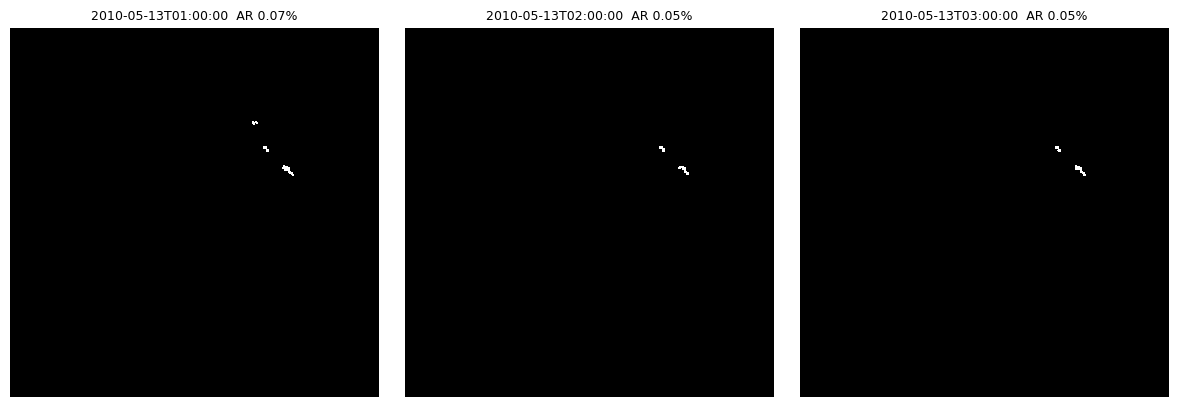

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, idx in zip(axes, range(3)):
    sample = train_dataset[idx]
    ax.imshow(sample["forecast"], cmap="gray", interpolation="nearest")
    ax.set_title(f"{sample['ds_index']}  AR {sample['forecast'].mean():.2%}", fontsize=9)
    ax.axis("off")
plt.tight_layout()

## Initialize with Surya stacks

Now the same dataset returns the full 13-channel input stack. Each sample is roughly 0.9 GB in
float32, and the first access of each timestep downloads its NetCDF file into the S3 cache.

### The 13 channels

| channel | instrument | what it shows |
|---|---|---|
| `aia94`, `aia131` | AIA (EUV) | hot flaring plasma (~6–10 MK) |
| `aia171`, `aia193`, `aia211`, `aia335` | AIA (EUV) | the corona at ~0.6–2.5 MK; loops over active regions |
| `aia304` | AIA (EUV) | chromosphere / transition region (He II) |
| `aia1600` | AIA (UV) | upper photosphere / transition region; plage stands out |
| `hmi_m` | HMI | line-of-sight magnetic field — **the channel the answer key is derived from** |
| `hmi_bx`, `hmi_by`, `hmi_bz` | HMI | the three vector-field components |
| `hmi_v` | HMI | Doppler velocity |

Because the answer key comes from `hmi_m`, a model can in principle imitate the rule from that
channel alone. Notebook 1's two-parameter baseline (a learned threshold on `hmi_m`) measures
how much of the task the rule already explains.


In [15]:
train_dataset = ARSegmentationDataset(
    index_path=cfg.data.train_data_path,
    time_delta_input_minutes=cfg.data.time_delta_input_minutes,
    time_delta_target_minutes=cfg.data.time_delta_target_minutes,
    n_input_timestamps=cfg.model.time_embedding.time_dim,
    rollout_steps=cfg.rollout_steps,
    channels=cfg.data.channels,
    drop_hmi_probability=cfg.drop_hmi_probability,
    use_latitude_in_learned_flow=cfg.use_latitude_in_learned_flow,
    scalers=scalers,
    phase="train",
    s3_mode=cfg.data.s3_mode,
    s3_storage_options={"anon": cfg.data.s3_anon},
    s3_cache_dir=cfg.data.s3_cache_dir,
    pooling=cfg.data.ar_pooling,
    #### Downstream (DS) specific parameters
    return_surya_stack=True,
    max_number_of_samples=6,
    ds_mask_dir=cfg.data.ar_mask_dir,
    ds_mask_splits=cfg.data.ar_mask_splits,
    ds_mask_key=cfg.data.ar_mask_key,
)

item = train_dataset[0]
print({k: (tuple(v.shape) if hasattr(v, "shape") else type(v).__name__) for k, v in item.items()})

{'ts': (13, 1, 4096, 4096), 'time_delta_input': (1,), 'forecast': (4096, 4096), 'ds_index': 'str'}


In Surya's convention:

- `ts`: input tensor of shape [C, T, H, W] (channels, timestamps, height, width)
- `time_delta_input`: minutes of each input frame relative to "now"
- `forecast`: here the [H, W] binary mask, instead of a future SDO stack

## Plot the input stack next to its mask

The inputs are stored in normalized (signum-log, z-scored) space. `inverse_transform_data`
returns physical units for plotting.

The magnetogram is drawn in physical units (gauss) so the ±50 G rule can be seen at work:
every white region in the mask sits on a patch containing **both** polarities close together.
Strong patches of a single polarity are unmarked — see step 5 of the rule above.


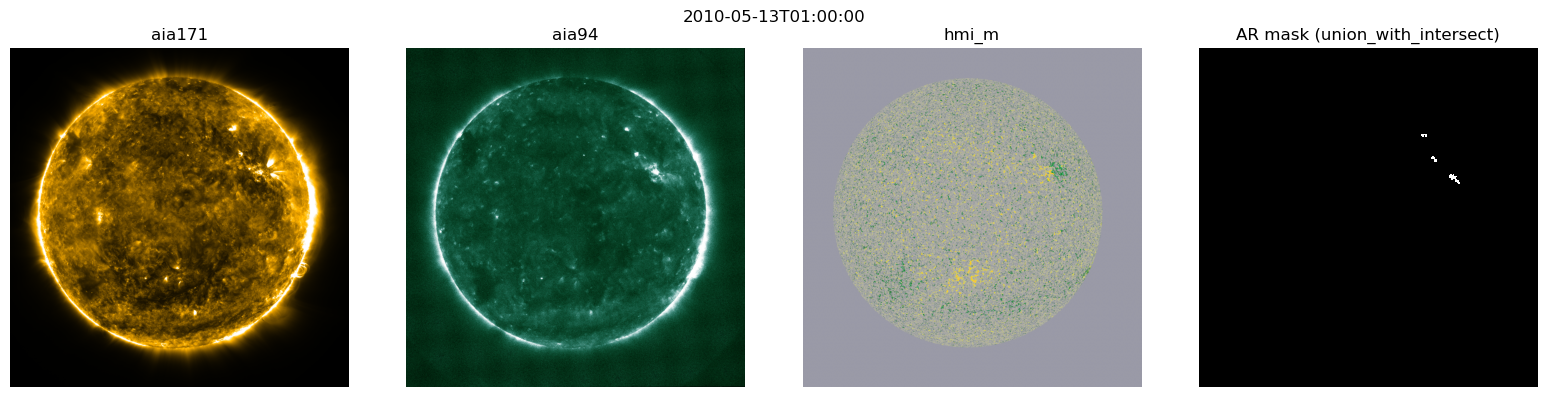

In [16]:
import sunpy.visualization.colormaps  # registers the sdoaia* / hmimag colormaps

physical = train_dataset.inverse_transform_data(item["ts"][:, 0, ...])
channels = cfg.data.channels
show = [c for c in ("aia171", "aia94", "hmi_m") if c in channels]

fig, axes = plt.subplots(1, len(show) + 1, figsize=(4 * (len(show) + 1), 4))
for ax, ch in zip(axes, show):
    i = channels.index(ch)
    img = physical[i]
    if "hmi" in ch:
        ax.imshow(img, cmap="hmimag", vmin=-1000, vmax=1000)
    else:
        ax.imshow(img, cmap=f"sdo{ch}", vmin=0, vmax=np.percentile(img[img != 0], 99))
    ax.set_title(ch)
    ax.axis("off")
axes[-1].imshow(item["forecast"], cmap="gray", interpolation="nearest")
axes[-1].set_title(f"AR mask ({cfg.data.ar_mask_key})")
axes[-1].axis("off")
plt.suptitle(item["ds_index"])
plt.tight_layout()

Look at the magnetogram (`hmi_m`) against the mask: every white region sits on a bipolar patch
of strong field. Strong-field patches with a single polarity are **not** labeled, because the
recipe requires a PIL. Keep this in mind when the model "false-positives" on them later.

## Define the dataloader

A DataLoader wraps the dataset with a sampling strategy and adds a batch dimension. Training
loaders shuffle; validation loaders do not. `build_helio_dataloaders()` (used in notebooks 1
and 2) sets these up from the config, including a seeded shuffle and `spawn` workers.

| what the loader adds | detail |
|---|---|
| a batch axis | `ts` becomes `[B, C, T, H, W]`, `forecast` becomes `[B, H, W]` |
| a sampling strategy | training loaders shuffle; validation loaders do not |
| a seeded shuffle | `build_helio_dataloaders()` (used in Notebooks 1–3) passes an explicit generator and `worker_init_fn`, so the epoch order depends only on the seed |
| worker processes | `spawn` context (the S3 handle does not survive `fork`); `persistent_workers=True` keeps them alive between epochs |

Sizing the workers: `free` and `nproc` report the whole node, not your container. Notebook 3
reads the real limits from `/sys/fs/cgroup/` and shows the arithmetic.


In [17]:
from torch.utils.data import DataLoader

data_loader = DataLoader(dataset=train_dataset, batch_size=2, shuffle=True)
batch = next(iter(data_loader))
print({k: (tuple(v.shape) if hasattr(v, "shape") else type(v).__name__) for k, v in batch.items()})

{'ts': (2, 13, 1, 4096, 4096), 'time_delta_input': (2, 1), 'forecast': (2, 4096, 4096), 'ds_index': 'list'}


`ts` is now [B, C, T, H, W] and `forecast` is [B, H, W]. The Lightning module in the next
notebooks adds a channel axis to the target, giving [B, 1, H, W] to match the model output.

## Conclusion

The dataset and dataloader are ready. Continue with **1_baseline_ar.ipynb**, which trains a
14-parameter per-pixel logistic regression and defines the metrics that every model, including
Surya, will be scored with.

| next | what it adds |
|---|---|
| `1_baseline_ar.ipynb` | the 14-parameter per-pixel model and the scorecard everything is judged by |
| `2_finetune_ar.ipynb` | Surya with adapters — same data, same scorecard, same loop |
| `3_errors_ar.ipynb` | intervals, calibration, contours, an ensemble, and the label floor |

### Numbers worth remembering

| quantity | value |
|---|---|
| image | 4096 × 4096, 13 channels, ≈ 0.87 GB per sample in float32 |
| cadence | images every 12 min; outlines hourly → 1 in 5 pairs |
| AR coverage | 0.02–1.8 % of the frame by year; ~55:1 at solar maximum, > 4,000:1 at minimum |
| labelling rule | ±50 G, ≥ 100 px, grow 10 px (square), must contain a PIL |
